In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df1=pd.read_csv(r'D:\RegAnalysis - Project\uber.csv')

In [66]:
df1.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [67]:
print(df1.shape)
print(df1.shape[0])

(200000, 9)
200000


In [68]:
df1.dtypes

Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [69]:
## Renameing the First column as ID:

df1.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)

In [70]:
df1.head()

,ID,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [71]:
#### Change the data type of column "pickup_datetime" into Datetime format:

df1['pickup_datetime']=pd.to_datetime(df1['pickup_datetime'])

In [72]:
df1.dtypes

ID                                 int64
key                               object
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dtype: object

In [73]:
## Handling the null values:

df1.isnull().sum().index

Index(['ID', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [74]:
df1.isnull().sum()

ID                   0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [75]:
df1[df1['dropoff_longitude'].isnull()].index

Index([87946], dtype='int64')

In [76]:
df1[df1['dropoff_latitude'].isnull()].index

Index([87946], dtype='int64')

In [77]:
## Dropping the Null values:

df1.dropna(inplace=True)

In [78]:
## To find the duplicates:

df1.duplicated().sum()

np.int64(0)

In [79]:
## Checking the rows containing the Null values are dropped:

df1.isnull().sum()

ID                   0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [80]:
df1.shape

(199999, 9)

In [81]:
df1.head()

,ID,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


In [82]:
### Summarize the whole dataset:

df1.describe()

,ID,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,1.601386e+07,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382534e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774524e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155535e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [37]:
#Cols_drop = ['hour','Dayofweek','Month','Year']

#df1.drop(columns=Cols_drop, inplace=True)

In [83]:
## Identifying the outliers using Boxplot:

num_cols=df1.select_dtypes(exclude=['object','datetime64[ns, UTC]']).columns
num_cols

Index(['ID', 'fare_amount', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

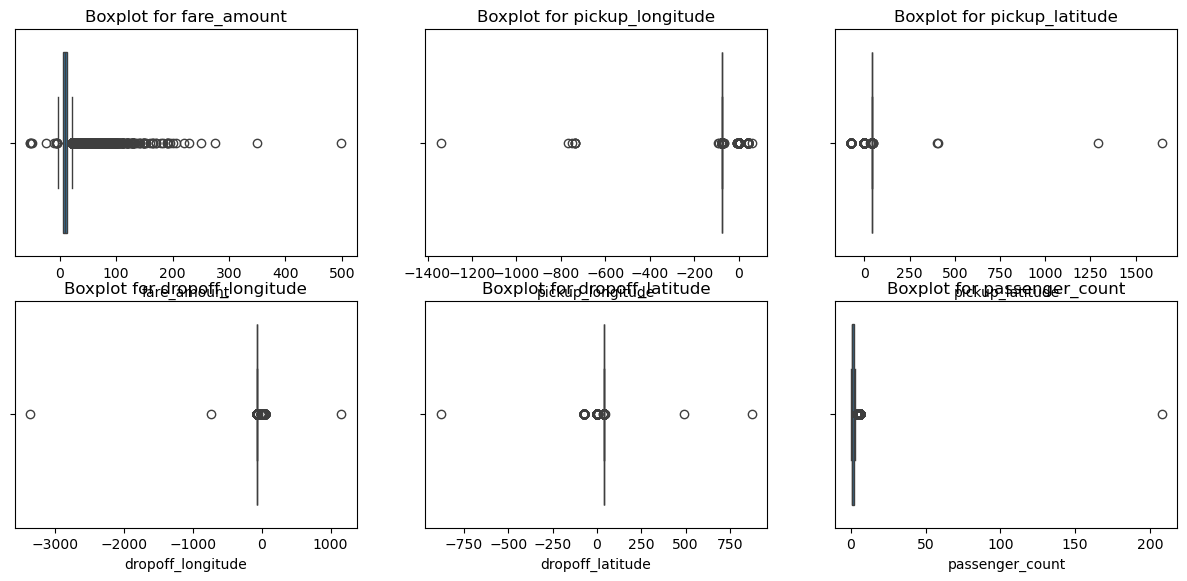

In [84]:
## EDA: using num_cols:

cols=num_cols

# By skipping the column 'ID' use slicing from [1:]
plt.figure(figsize=(15,10))
for i in range(len(cols[1:])):
    plt.subplot(3,3,i+1)
    sns.boxplot(data=df1, x=cols[i+1])
    plt.title(f'Boxplot for {cols[i+1]}')
plt.show

In [85]:
## Treating the outliers:

d1=df1[num_cols].describe(percentiles=[0.01,0.02,0.03,0.04,0.05,0.95,0.97,0.98,0.99]).T
d1 = d1.iloc[1:,3:]
d1

,min,1%,2%,3%,4%,5%,50%,95%,97%,98%,99%,max
fare_amount,-52.000000,3.300000,3.500000,3.700000,4.000000,4.100000,8.500000,30.330000,38.830000,47.540000,53.300000,499.000000
pickup_longitude,-1340.648410,-74.014402,-74.010428,-74.008760,-74.007795,-74.006838,-73.981823,-73.871199,-73.786988,-73.137393,0.000000,57.418457
pickup_latitude,-74.015515,0.000000,40.604666,40.645455,40.680999,40.701801,40.752592,40.787702,40.794117,40.799795,40.806606,1644.421482
dropoff_longitude,-3356.666300,-74.015288,-74.012215,-74.009957,-74.008408,-74.007460,-73.980093,-73.874212,-73.801836,-73.547828,0.000000,1153.572603
dropoff_latitude,-881.985513,0.000000,40.579128,40.646968,40.673488,40.686410,40.753042,40.793744,40.803791,40.809840,40.829479,872.697628
passenger_count,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,6.000000,6.000000,208.000000


In [86]:
df2=df1.copy()

In [87]:
left_sk_cols=['fare_amount','pickup_longitude','dropoff_longitude','passenger_count']

right_sk_cols=['fare_amount','pickup_latitude','dropoff_latitude','passenger_count']

In [88]:
for i in left_sk_cols:
    lower=df1[i].quantile(0.01)
    df1[i]=np.where(df1[i]<lower, lower, df1[i])

In [89]:
for i in right_sk_cols:
    upper=df1[i].quantile(0.99)
    df1[i]=np.where(df1[i]>upper, upper, df1[i])

In [90]:
### Checking the treated outliers for left and right skewed columns:

d1=df1[num_cols].describe(percentiles=[0.01,0.02,0.03,0.04,0.05,0.95,0.97,0.98,0.99]).T
d1 = d1.iloc[1:,3:]
d1

,min,1%,2%,3%,4%,5%,50%,95%,97%,98%,99%,max
fare_amount,3.300000,3.300000,3.500000,3.700000,4.000000,4.100000,8.500000,30.330000,38.830000,47.540000,53.300000,53.300000
pickup_longitude,-74.014402,-74.014402,-74.010428,-74.008760,-74.007795,-74.006838,-73.981823,-73.871199,-73.786988,-73.137393,0.000000,57.418457
pickup_latitude,-74.015515,0.000000,40.604666,40.645455,40.680999,40.701801,40.752592,40.787702,40.794117,40.799795,40.806606,40.806606
dropoff_longitude,-74.015288,-74.015288,-74.012215,-74.009957,-74.008408,-74.007460,-73.980093,-73.874212,-73.801836,-73.547828,0.000000,1153.572603
dropoff_latitude,-881.985513,0.000000,40.579128,40.646968,40.673488,40.686410,40.753042,40.793744,40.803791,40.809840,40.829478,40.829479
passenger_count,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,6.000000,6.000000,6.000000


In [91]:
### Treating the outliers for Latitudes and Longitudes columns separately:

lats_cols=['pickup_latitude','dropoff_latitude']

for i in lats_cols:
    df1[i]=np.where(df1[i]<40.5, 40.5, df1[i])


In [93]:
longs_cols=['pickup_longitude','dropoff_longitude']

for i in longs_cols:
    df1[i]=np.where(df1[i]>-70.0, -73.7, df1[i])

In [94]:
### Checking the overall treated outlliers:

d1=df1[num_cols].describe(percentiles=[0.01,0.02,0.03,0.04,0.05,0.95,0.97,0.98,0.99]).T
d1 = d1.iloc[1:,3:]
d1

,min,1%,2%,3%,4%,5%,50%,95%,97%,98%,99%,max
fare_amount,3.300000,3.300000,3.500000,3.700000,4.000000,4.100000,8.500000,30.330000,38.830000,47.540000,53.300000,53.300000
pickup_longitude,-74.014402,-74.014402,-74.010428,-74.008760,-74.007795,-74.006838,-73.981823,-73.871199,-73.786988,-73.700000,-73.700000,-71.004193
pickup_latitude,40.500000,40.500000,40.604666,40.645455,40.680999,40.701801,40.752592,40.787702,40.794117,40.799795,40.806606,40.806606
dropoff_longitude,-74.015288,-74.015288,-74.012215,-74.009957,-74.008408,-74.007460,-73.980093,-73.874212,-73.801836,-73.700000,-73.700000,-71.004193
dropoff_latitude,40.500000,40.500000,40.579128,40.646968,40.673488,40.686410,40.753042,40.793744,40.803791,40.809840,40.829478,40.829479
passenger_count,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,6.000000,6.000000,6.000000


In [95]:
## Feature Engineering:

df1['hour']=df1['pickup_datetime'].dt.hour
df1['Dayofweek']=df1['pickup_datetime'].dt.dayofweek
df1['Month']=df1['pickup_datetime'].dt.month
df1['Year']=df1['pickup_datetime'].dt.year

In [99]:
df1.head()

,ID,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,Dayofweek,Month,Year,lat_diff,long_diff,dist_km
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1.0,19,3,5,2015,-0.015137,0.000305,1.714050
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1.0,20,4,7,2009,0.022100,-0.000355,2.492505
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1.0,21,0,8,2009,0.031877,0.042478,8.253405
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3.0,8,4,6,2009,0.012505,0.010808,2.587743
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5.0,17,3,8,2014,0.017162,-0.048059,7.239531


In [98]:
### Converting the Degree of latitude and longitude into KM:

df1['lat_diff']=df1['dropoff_latitude']-df1['pickup_latitude']
df1['long_diff']=df1['dropoff_longitude']-df1['pickup_longitude']

df1['dist_km']= (abs(df1['lat_diff']) + abs(df1['long_diff'])) * 111
df1['dist_km']

0          1.714050
1          2.492505
2          8.253405
3          2.587743
4          7.239531
            ...    
199995     0.160617
199996     2.745363
199997    21.196449
199998     4.877930
199999     5.531019
Name: dist_km, Length: 199999, dtype: float64

In [100]:
## Selecting x and y from the Dataset:

x=df1.drop(['ID','key','fare_amount','pickup_datetime'], axis=1)
y=df1['fare_amount']

In [101]:
print(x.shape)
print(y.shape)

(199999, 12)
(199999,)


In [159]:
df1.columns

Index(['ID', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'hour', 'Dayofweek', 'Month', 'Year', 'lat_diff',
       'long_diff', 'dist_km'],
      dtype='object')

In [127]:
## Split the dataset:

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.3, random_state=42)

In [129]:
print(x_train.shape,y_train.shape)
print(x_test.shape, y_test.shape)

(139999, 12) (139999,)
(60000, 12) (60000,)


In [130]:
print(x_train.columns)

Index(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'Dayofweek', 'Month',
       'Year', 'lat_diff', 'long_diff', 'dist_km'],
      dtype='object')


In [131]:
### Scaling:

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [158]:
x_train.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,Dayofweek,Month,Year,lat_diff,long_diff,dist_km
194320,-73.989801,40.741791,-73.993203,40.752921,1.0,14,3,8,2009,0.011130,-0.003402,1.613052
774,-73.983210,40.734950,-73.953570,40.788012,2.0,2,5,8,2014,0.053062,0.029640,9.179922
75676,-73.954445,40.789724,-73.986493,40.777593,1.0,17,2,4,2013,-0.012131,-0.032048,4.903869
37127,-73.982404,40.723422,-74.000441,40.720880,1.0,8,4,7,2014,-0.002542,-0.018037,2.284269
96757,-73.961700,40.773402,-73.988590,40.764037,5.0,20,6,8,2010,-0.009365,-0.026890,4.024305


In [133]:
### Training the x_train on Scaling:

x_train_sc = sc.fit_transform(x_train)

x_test_sc = sc.transform(x_test)

print(x_train_sc.shape)

(139999, 12)


In [134]:
print(type(x_train))

<class 'pandas.core.frame.DataFrame'>


In [135]:
### Reviewing the result post using Scaling function:

print(x_train_sc[:2, :3])

[[-0.36995792 -0.08859324 -0.45718852]
 [-0.24987608 -0.24496873  0.27272814]]


In [136]:
### Correlation Analysis:

df1.head()

,ID,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,Dayofweek,Month,Year,lat_diff,long_diff,dist_km
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1.0,19,3,5,2015,-0.015137,0.000305,1.714050
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1.0,20,4,7,2009,0.022100,-0.000355,2.492505
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1.0,21,0,8,2009,0.031877,0.042478,8.253405
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3.0,8,4,6,2009,0.012505,0.010808,2.587743
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5.0,17,3,8,2014,0.017162,-0.048059,7.239531


In [138]:
corr = df1.drop(['ID','key','pickup_datetime'], axis=1).corr()
corr

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,Dayofweek,Month,Year,lat_diff,long_diff,dist_km
fare_amount,1.000000,0.276932,-0.138032,0.242351,-0.136130,0.012709,-0.021335,0.006240,0.025367,0.121873,-0.006302,-0.045871,0.762316
pickup_longitude,0.276932,1.000000,-0.566304,0.688753,-0.478348,-0.003483,0.015266,-0.013953,0.001318,0.007804,0.088566,-0.401123,0.246227
pickup_latitude,-0.138032,-0.566304,1.000000,-0.505645,0.743991,-0.004483,0.015781,-0.025637,0.002621,-0.014897,-0.300140,0.081097,-0.101964
dropoff_longitude,0.242351,0.688753,-0.505645,1.000000,-0.473802,-0.002906,-0.029048,-0.001082,0.003894,0.004703,0.012423,0.387838,0.234110
dropoff_latitude,-0.136130,-0.478348,0.743991,-0.473802,1.000000,-0.002478,0.014194,-0.021528,-0.000242,-0.010830,0.414081,0.009507,-0.064476
passenger_count,0.012709,-0.003483,-0.004483,-0.002906,-0.002478,1.000000,0.014538,0.035724,0.008801,0.005266,0.002570,0.000757,0.007227
hour,-0.021335,0.015266,0.015781,-0.029048,0.014194,0.014538,1.000000,-0.086956,-0.003924,0.002162,-0.001235,-0.056109,-0.026006
Dayofweek,0.006240,-0.013953,-0.025637,-0.001082,-0.021528,0.035724,-0.086956,1.000000,-0.008785,0.006116,0.004191,0.016372,0.009888
Month,0.025367,0.001318,0.002621,0.003894,-0.000242,0.008801,-0.003924,-0.008785,1.000000,-0.115860,-0.003916,0.003245,0.009700
Year,0.121873,0.007804,-0.014897,0.004703,-0.010830,0.005266,0.002162,0.006116,-0.115860,1.000000,0.004832,-0.003979,0.033069


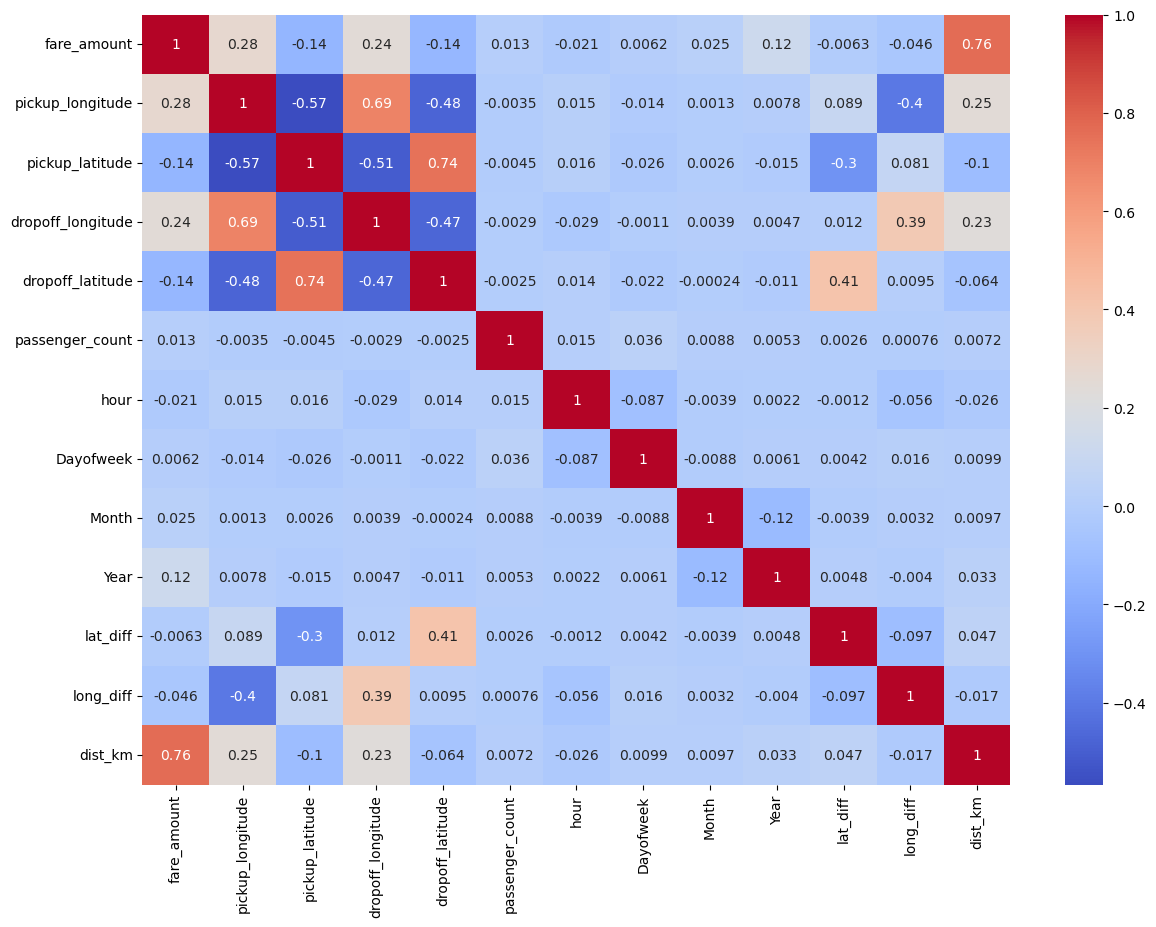

In [144]:
### Visualize the correlation using Heatmap:
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [145]:
## Select the model: Linear Regression (Target continuous in nature):

from sklearn.linear_model import LinearRegression

In [148]:
## Train the model:

model = LinearRegression()

model.fit(x_train,y_train)

LinearRegression()

In [153]:
## Test the data:

ypred_lr = model.predict(x_test)
print(len(ypred_lr))

60000


In [154]:
## Extracting the coefficient(m) and intercept(c): y=mx+c

coeffi = model.coef_
intercept = model.intercept_

print('Slope',coeffi)
print('Constant',intercept)

Slope [ 8.91802833e+00  8.08121814e-01  4.72565113e+00 -7.20436932e+00
  6.14608919e-02 -5.02154421e-03 -4.53885492e-03  7.71546584e-02
  4.83770666e-01 -8.01249114e+00 -4.19237720e+00  1.12722750e+00]
Constant 301.90351909696517


In [152]:
### Evaluate the models using Reg metrics:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [156]:
def reg_model(ytest, ypred):
    mae=mean_absolute_error(ytest, ypred)
    mse=mean_squared_error(ytest, ypred)
    rmse=np.sqrt(mse)
    r2=r2_score(ytest, ypred)
    print('MAE', mae, 'MSE', mse, 'RMSE', rmse)
    print('R2', r2)

In [157]:
reg_model(y_test, ypred_lr)

MAE 2.9002236644797947 MSE 34.427826956115084 RMSE 5.86752306822181
R2 0.5766519860018101


In [161]:
print('Train Score',model.score(x_train,y_train))  # Train R2 
print('Test Score',model.score(x_test,y_test))

Train Score 0.6139600208648375
Test Score 0.5766519860018101


In [162]:
## To improve the Train and test scores, implementing the Rnandom Forest Regressor:

from sklearn.ensemble import RandomForestRegressor

In [164]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


In [165]:
## Train the data using Random Forest Regressor:

rf.fit(x_train,y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [168]:
## Predict the scores of train and test data:

rf_train = rf.predict(x_train)
rf_test = rf.predict(x_test)

print('Train score', rf_train, 'Test score', rf_test)

Train score [ 6.255  15.675  13.89   ...  8.979   6.02   27.9093] Test score [ 7.156  4.936 14.945 ...  7.631  5.616  9.34 ]


In [169]:
train_r2 = r2_score(y_train, rf_train)
test_r2 = r2_score(y_test, rf_test)

print('Train R2_score', train_r2, 'Test R2_score', test_r2)

Train R2_score 0.9751453852078142 Test R2_score 0.8208213106693956


In [171]:
## Comparing both the Train and Test R2_scores of LinearReg and RandomForestRegressor:

print('LinearReg')
print('Train Score',model.score(x_train,y_train))  # Train R2 
print('Test Score',model.score(x_test,y_test))

print('RandomForestReg')
print('Train R2_score', rf.score(x_train,y_train))
print('Test R2_score', rf.score(x_test,y_test))

LinearReg
Train Score 0.6139600208648375
Test Score 0.5766519860018101
RandomForestReg
Train R2_score 0.9751453852078142
Test R2_score 0.8208213106693956


In [172]:
### Using the RandomizedSearchCV:

from sklearn.model_selection import RandomizedSearchCV

In [174]:
param_dist = {
    'n_estimators': [100, 200],               
    'max_depth': [10, 20, 30, None],          
    'min_samples_split': [2, 5, 10],          
    'min_samples_leaf': [1, 2, 4],            
    'max_features': ['sqrt', 'log2', None]}

In [177]:
rf_randomCV = RandomizedSearchCV(estimator=rf, 
    param_distributions=param_dist, 
    n_iter=5, 
    cv=3, 
    verbose=2, 
    random_state=42, 
    n_jobs=1)

In [178]:
rf_randomCV.fit(x_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 2.8min
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 2.8min
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 2.5min
[CV] END max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time= 2.3min
[CV] END max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time= 2.2min
[CV] END max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time= 2.2min
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=  21.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_est

RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=5, n_jobs=1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200]},
                   random_state=42, verbose=2)

In [180]:
print("--- Tuned Random Forest Scores ---")
print('Train R2_score:', rf_randomCV.score(x_train, y_train))
print('Test R2_score:', rf_randomCV.score(x_test, y_test))

--- Tuned Random Forest Scores ---
Train R2_score: 0.9085353870180345
Test R2_score: 0.8322768719370583


In [ ]:
## It confirms that distance is the primary "engine" of regression model

## Bu utilising the RandomForestReg the Train score has been drastically reduced with a slight increase in Test score

In [ ]:
## Inference:

## Overfitting is minimized using RandomizeSearchCV.

In [181]:
x_train.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,Dayofweek,Month,Year,lat_diff,long_diff,dist_km
194320,-73.989801,40.741791,-73.993203,40.752921,1.0,14,3,8,2009,0.011130,-0.003402,1.613052
774,-73.983210,40.734950,-73.953570,40.788012,2.0,2,5,8,2014,0.053062,0.029640,9.179922
75676,-73.954445,40.789724,-73.986493,40.777593,1.0,17,2,4,2013,-0.012131,-0.032048,4.903869
37127,-73.982404,40.723422,-74.000441,40.720880,1.0,8,4,7,2014,-0.002542,-0.018037,2.284269
96757,-73.961700,40.773402,-73.988590,40.764037,5.0,20,6,8,2010,-0.009365,-0.026890,4.024305


In [183]:
x_train.columns

Index(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'Dayofweek', 'Month',
       'Year', 'lat_diff', 'long_diff', 'dist_km'],
      dtype='object')

In [182]:
## Save the model:

import pickle

In [185]:
pickle.dump(model,open('Uber_fareamountpredict_lr.pkl','wb'))
pickle.dump(rf_randomCV,open('Uber_fareamountpredict_rf.pkl','wb'))

In [ ]:
## Predicting the model by new data:

test = [[-73.98, 40.75, -73.99, 40.73, 1, 18, 0, 4, 2026, 0.02, 0.01, 2.0]]